# <b><u> Project Title : Seoul Bike Sharing Demand Prediction </u></b>

Currently Rental bikes are introduced in many urban cities for the enhancement of mobility. It is important to make the rental bikes available and accessible to the public at the right time. Eventually, providing the city with a stable supply of rental bikes becomes a major concern. The crucial part is the prediction of bike count required at each hour for the stable supply of rental bikes.

<html>
<img src="https://cdn.dribbble.com/users/362212/screenshots/2831376/biker.gif" width="400" height="300" alt="bike">
</html>

## <b> Data Description </b>



The dataset contains weather information (Temperature, Humidity, Windspeed, Visibility, Dewpoint, Solar radiation, Snowfall, Rainfall), the number of bikes rented per hour and date information.


### <b style="color:SeaGreen;font-family:verdana">Attribute Information: </b>

*  Date : year-month-day
*  Rented Bike count - Count of bikes rented at each hour
*  Hour - Hour of he day
*  Temperature-Temperature in Celsius
*  Humidity - %
*  Windspeed - m/s
*  Visibility - 10m
*  Dew point temperature - Celsius
*  Solar radiation - MJ/m2
*  Rainfall - mm
*  Snowfall - cm
*  Seasons - Winter, Spring, Summer, Autumn
*  Holiday - Holiday/No holiday
*  Functional Day - NoFunc(Non Functional Hours), Fun(Functional hours)

-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.


## Project Flowchart:

1. Loading data and Diagnosing the data
2. Data Filtering 
3. EDA of Row data to understand inside correlations
4. Feature Engineering
5. Feature Selection
6. Model Building
7. Model Training and Testing
8. Model Evalution & Hyper Perameter tuning

----

## **1. Import Libraries and Data**


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import rootpath

rootpath.append()

from src.constants import REPO_NAME, REPO_OWNER, TRACKING_URI
from sklearn.model_selection import train_test_split, GridSearchCV,  cross_val_score
from sklearn import preprocessing, linear_model
from sklearn.preprocessing import  LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 
from sklearn.metrics import r2_score, root_mean_squared_error, accuracy_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn import neighbors
from sklearn.svm import SVR
from sklearn import tree
from ucimlrepo import fetch_ucirepo

import xgboost as xgb
from xgboost import plot_importance

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

pd.pandas.set_option('display.max_columns',None)
%matplotlib inline

###*1.1 _ Data Loading*

We can now create a Pandas dataframe using ucimlrepo, to view and analyze the data.

In [2]:
# Fetch dataset
seoul_bike_sharing_demand = fetch_ucirepo(id=560)

# Load data
data = seoul_bike_sharing_demand.data.original

#####1.1.1 _ First Look at the Data

In [3]:
data.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


The dataset contains 8760 rows and 14 columns. Each row of the dataset contains information about weather conditions

|Column| Data details inside column |
|------|----------------------------|
|Date| Date of Rented Bike | 
|Rented Bike count | Number of total rentals|
|Hour | Hours of the day |
|Temperature(°C)| Weather Temperature in °C |
|Humidity(%)| Humidity of the day in %|
|	Wind speed (m/s)| Wind speed in m/s |
|Visibility (10m)| Atmospherical Visibility within 10 𝑚 range |
|Dew point temperature(°C) | Dew Point Temperature - T dp in °C |
|Solar Radiation (MJ/m2) | Indicate light and energy that comes from the sun in MJ/m2 | 
|Rainfall(mm)	| Rain fall in mm |
|Snowfall (cm) | Snow fall in cm |
|Seasons| Autumn, Spring, Summer, Winter |
|Holiday|Whether the day is considered a holiday|	
|Functioning Day|Whether the day is neither a weekend nor holiday|



Our objective is to find a way to estimate the value prediction of bike count required at each hour for the stable supply of rental bikes. using the values in the other columns. If we can do so for the historical data, then we should able to estimate bike count required at each hour.

#### 1.1.2 Checking the duplicate entries in data

In [4]:
# Check for duplicated entries.
print("Duplicate entry in data:",len(data[data.duplicated()])) 

Duplicate entry in data: 0


Not found any duplicated entries inside the data

### *1.2 _ Diagnosing the Data*



In [5]:
# Custom Function for Dtype,Unique values and Null values
def datainfo():
    temp_ps = pd.DataFrame(index=data.columns)
    temp_ps['DataType'] = data.dtypes
    temp_ps["Non-null_Values"] = data.count()
    temp_ps['Unique_Values'] = data.nunique()
    temp_ps['NaN_Values'] = data.isnull().sum()
    temp_ps['NaN_Values_Percentage'] = (temp_ps['NaN_Values']/len(data))*100 
    return temp_ps

In [6]:
# Shape of the data.
print("Total Rows and Columns in DataFrame is :",data.shape,"\n") 
# Custom Function
datainfo()

Total Rows and Columns in DataFrame is : (8760, 14) 



,DataType,Non-null_Values,Unique_Values,NaN_Values,NaN_Values_Percentage
Date,object,8760,365,0,0.0
Rented Bike Count,int64,8760,2166,0,0.0
Hour,int64,8760,24,0,0.0
Temperature,float64,8760,546,0,0.0
Humidity,int64,8760,90,0,0.0
Wind speed,float64,8760,65,0,0.0
Visibility,int64,8760,1789,0,0.0
Dew point temperature,float64,8760,556,0,0.0
Solar Radiation,float64,8760,345,0,0.0
Rainfall,float64,8760,61,0,0.0


Finding details from data:

1. There are 14 features with 8760 rows of data.
2. There are 4 categorical columns and 10 numerical columns. Columns ‘Date’, ‘Seasons’ and ‘Functioning Day’ are of 𝑜𝑏𝑗𝑒𝑐𝑡 data type
3. Columns ‘Rented Bike Count’, ‘Hour’, ‘Humidity (%)' and ‘Visibility (10𝑚)' are of 𝑖𝑛𝑡64 numarical data type
4. Columns ‘Temperature Temperature (℃)’, ‘Wind Speed (𝑚/𝑠)’, ‘Dew Point Temperature (℃)’,‘Solar Radiation (𝑀𝐽/𝑚2)’,‘Rainfall (𝑚𝑚)' and ‘Snowfall(𝑐𝑚) are of 𝑓𝑙𝑜𝑎𝑡64 numarical data type
5. Not any null value present in any column
6. Unique count : Seasons- 4 , Holiday- 2 , Functioning Day- 2

In [7]:
# Statistical info.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature,8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity,8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed,8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility,8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature,8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation,8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall,8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall,8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


The ranges of values in the numerical columns seem reasonable too, so we may not have to do much data cleaning. The "Wind speed","Dew point temperature(°C)", "Solar Radiation", "Rainfall" and "Snowfall" column seems to be significantly skewed however, as the median (50 percentile) is much lower than the maximum value.

## **2. Data Filtering**

### *2.1_Rented Bike days Filtering*

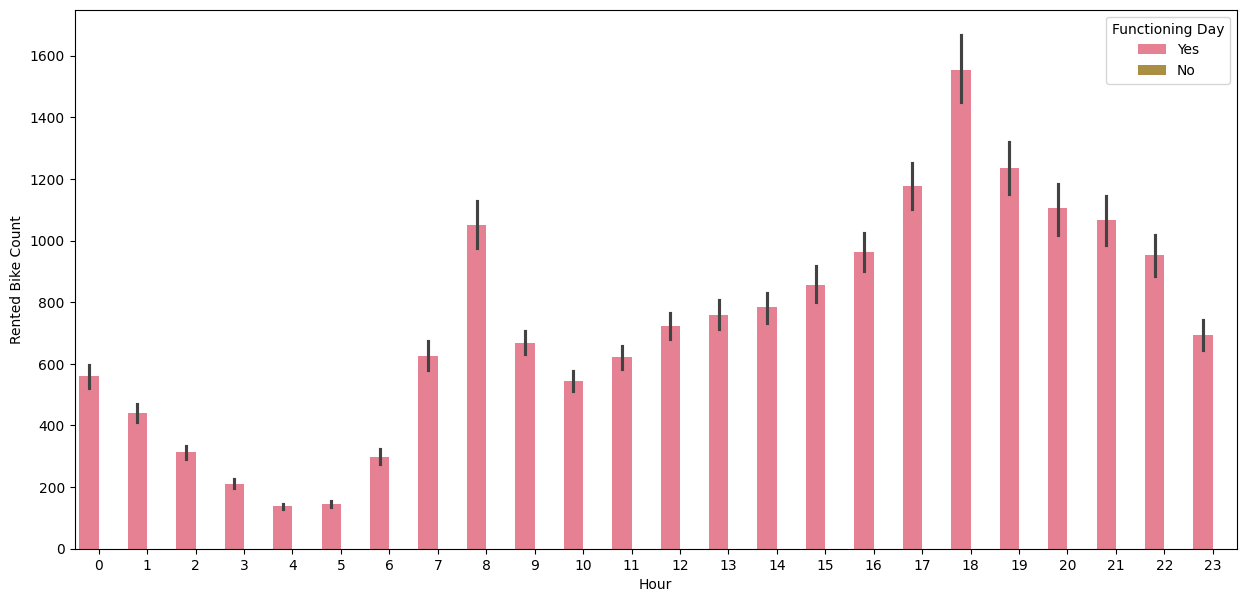

In [8]:
#for checking functioning and non functioning day ,plot (Hour Vs Rented Bike Count Graph)
def barplots(x,y,hue):
    plt.figure(figsize=(15,7))
    sns.set_palette("husl")
    sns.barplot(x=x,y=y,hue=hue,data=data);
barplots('Hour','Rented Bike Count','Functioning Day')

In [9]:
# Grouping by functioning day and calculating the total Rented Bike Count
data.groupby('Functioning Day').sum()['Rented Bike Count'].sort_values(ascending = False).reset_index()

,Functioning Day,Rented Bike Count
0,Yes,6172314
1,No,0


Diagnosising the data found that the rental bike count is only given for Functioning Day, So remove Non Functioning Days and then remove Functioning Day Column as well

In [10]:
#Removing data of non functional days
df=data.drop(data[data['Functioning Day'] == 'No'].index) 

In [11]:
#Remove Functioning Day Column
df1=df.drop(['Functioning Day'], axis = 1)

In [12]:
#Checking DataFrame Shape After Removing Non Functional Day Rows And Functional Day Column
print("Filtered Dataframe with only rented bike days :",df1.shape,"\n") 

Filtered Dataframe with only rented bike days : (8465, 13) 





### *2.2 _ Seperate Date, Month, Year from Date Column*

First, let's convert `Date` to a `datecolumn` and extract different parts of the date.

In [13]:
#convert in datetime64[ns] datatype
df1['Date'] = pd.to_datetime(df1['Date'], format='%d/%m/%Y') 
df1['Date']

0      2017-12-01
1      2017-12-01
2      2017-12-01
3      2017-12-01
4      2017-12-01
          ...    
8755   2018-11-30
8756   2018-11-30
8757   2018-11-30
8758   2018-11-30
8759   2018-11-30
Name: Date, Length: 8465, dtype: datetime64[ns]

In [14]:
#Seperate Day, Month, Year from DataFrame Column

df1['Day']=df1['Date'].dt.day
df1['Month']=df1['Date'].dt.month
df1['Year']=df1['Date'].dt.year

In [15]:
# drop the Date column after extracting necessory information
df1.drop(columns=['Date'],inplace=True)

##**3. Exploratory Analysis and Visualization**

Let's explore the data by visualizing the distribution of values in some columns of the dataset, and the relationships between "Rented Bike count" and other columns.


> We'll use libraries Matplotlib, Seaborn for visualization.




###*3.1 _ Checking Correlation Of Data*

Correlation is a statistical measure that expresses the strength of the relationship between two variables. 

The two main types of correlation : **positive and negative.** 

**Positive correlation** occurs when two variables move in the same direction; as one increases, so do the other.

**Negative correlation** occurs when two variables move in opposite directions; as one increases, the other decreases. 

Correlation can be used to test hypotheses about cause and effect relationships between variables. Correlation is often used in the real world to predict trends.

<Axes: >

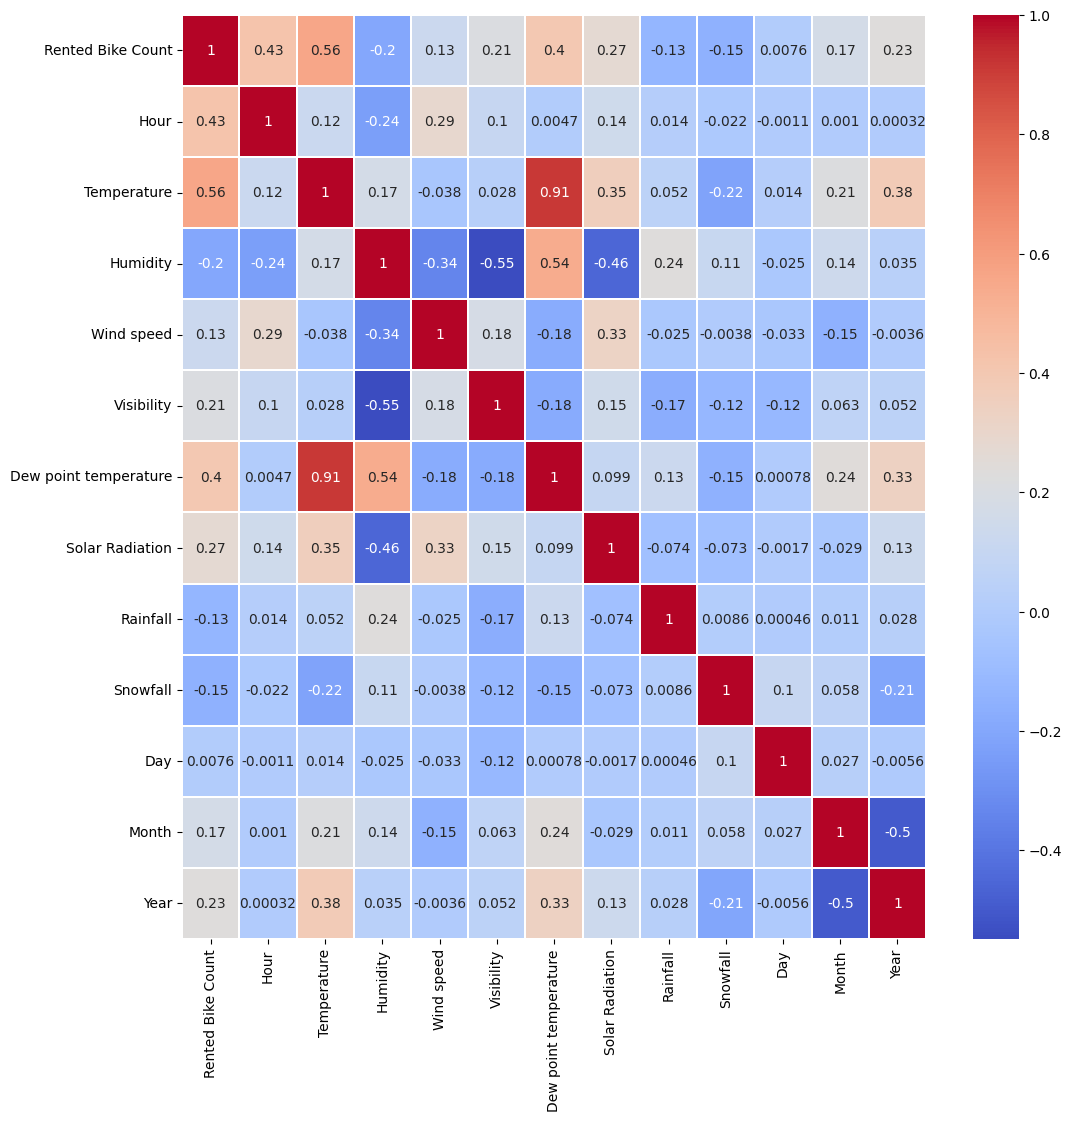

In [16]:
data_corr= df1.corr(numeric_only=True)       
plt.figure(figsize=(12,12))

sns.heatmap(data_corr, cmap='coolwarm', linewidths=0.1, annot=True, linecolor='white')

`temperature` and `Dew point temperature` are 0.91 correlated, and is generating multicollinearity. so we drop `Dew point temperature` feature

In [17]:
#Drop Dew point temperature(°C) from dataset df1
df1.drop(columns=['Dew point temperature'],inplace=True)  

Finding Insights:

1. We can see that with our target variable (Rented Bike Count), the most correlated variables are : Hour, Temperature, Dew point temperature

###*3.2 _ Separate Numerical And Categorical Variables*

#### Numerical Variables

In [18]:
#if dtype is not Equal to object type then its a num data
numerical_features=[col for col in df1.columns if df1[col].dtype!='O']
numerical_features

['Rented Bike Count',
 'Hour',
 'Temperature',
 'Humidity',
 'Wind speed',
 'Visibility',
 'Solar Radiation',
 'Rainfall',
 'Snowfall',
 'Day',
 'Month',
 'Year']

In [19]:
# Seprate dataframe for Numerical feature
num_data=df1[numerical_features]
num_data

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Solar Radiation,Rainfall,Snowfall,Day,Month,Year
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,1,12,2017
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,1,12,2017
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,1,12,2017
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,1,12,2017
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,1,12,2017
...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,0.0,0.0,0.0,30,11,2018
8756,764,20,3.4,37,2.3,2000,0.0,0.0,0.0,30,11,2018
8757,694,21,2.6,39,0.3,1968,0.0,0.0,0.0,30,11,2018
8758,712,22,2.1,41,1.0,1859,0.0,0.0,0.0,30,11,2018


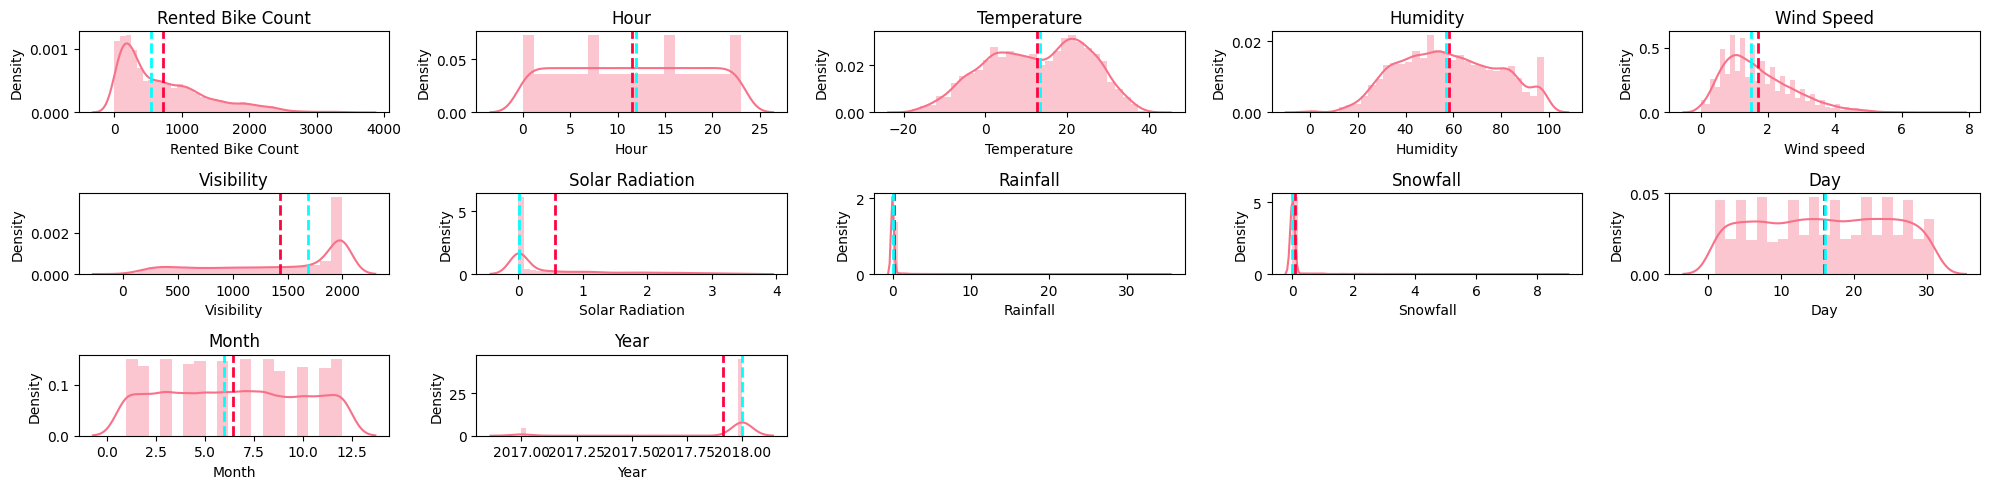

In [20]:
#plot num data for analysis of data distributions
fig = plt.figure(figsize = (20,5))
for index,column in enumerate(numerical_features) :
  plt.subplot(3,5,index+1)
  sns.distplot(df1[column])
  feature = df1[column]
  ax = fig.gca()
  ax.axvline(feature.mean(), color='#ff033e', linestyle='dashed', linewidth=2)  #Rose-Red Color indicate mean of data
  ax.axvline(feature.median(), color='#00ffff', linestyle='dashed', linewidth=2) #Cyan indicate median of data
  plt.title(f'{column.title()}')
  plt.tight_layout()

In [21]:
df1[numerical_features].agg(['skew', 'kurtosis']).transpose()

,skew,kurtosis
Rented Bike Count,1.139700,0.820305
Hour,-0.001261,-1.203446
Temperature,-0.174550,-0.889578
Humidity,0.068649,-0.812228
Wind speed,0.894222,0.754256
Visibility,-0.695306,-0.969125
Solar Radiation,1.510065,1.145102
Rainfall,14.616921,289.963779
Snowfall,8.292830,90.542378
Day,-0.018521,-1.183248



Right/Positive Skewed Distribution: Mode < Median < Mean: Rented Bike Count, Wind Speed(m/s), Solar Radiation(MJ/m2)

No Skew: Mean = Median = Mode : Hour, Temperature, Humidity(%),Rainfall(mm),Snowfall(cm)


Left/Negative Skewed Distribution: Mean < Median < Mode: visibility(10m)

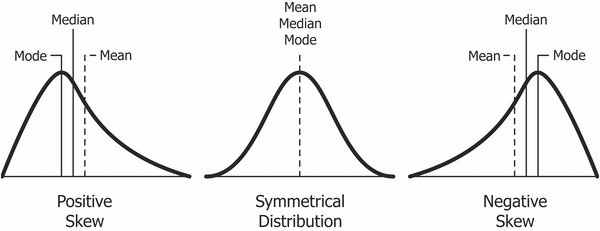

#####Discrete Values

Discrete Variables Count: 4


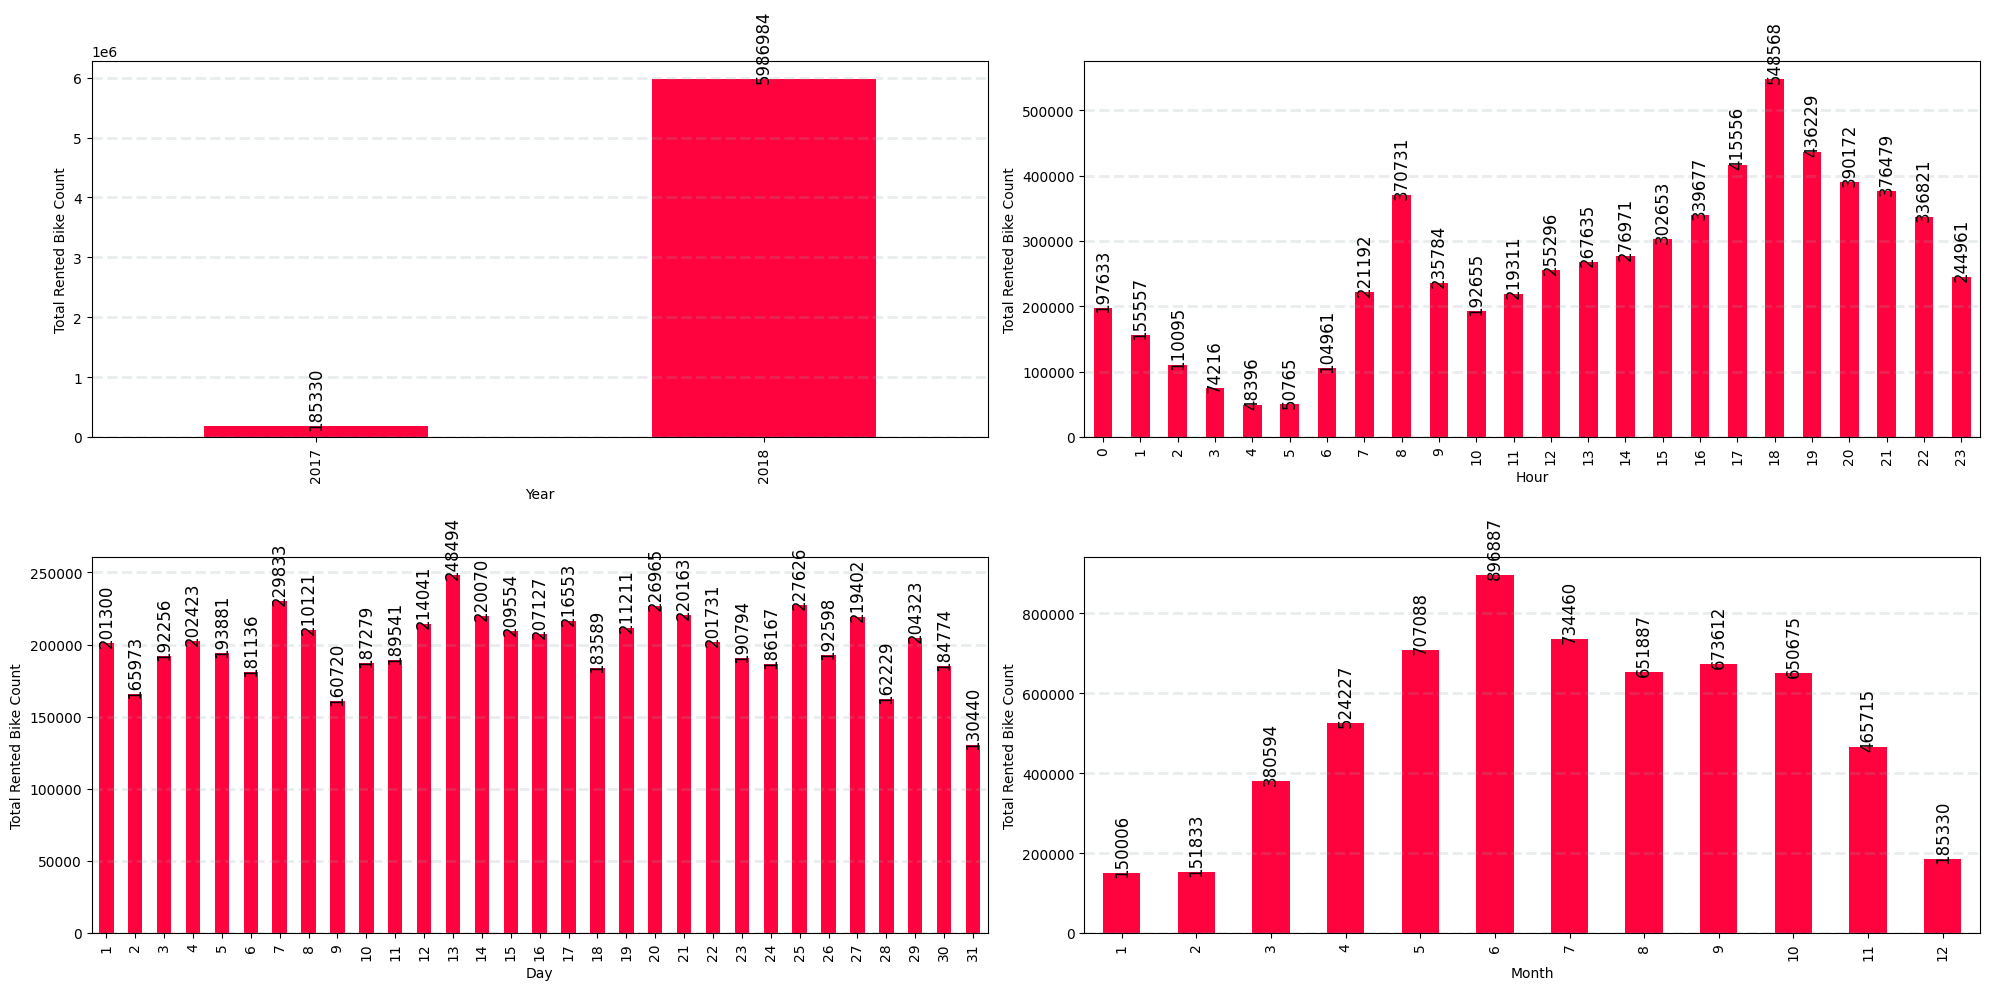

In [22]:
## Lets analyse the discrete values by creating histograms to understand the distribution
num_discrete_value=[feature for feature in numerical_features if len(df1[feature].unique())<32]
print("Discrete Variables Count: {}".format(len(num_discrete_value)))

fig = plt.figure(figsize = (20,10))
for index,column in enumerate(num_discrete_value) :
  plt.subplot(2,2,index+1)
  dataset=df1.copy()
  dataset.groupby(feature)['Rented Bike Count'].sum().plot(kind='bar',color="#ff033e") #kind=bar use for ploting barchart
  feature = df1[column]
  ax = fig.gca()
  plt.ylabel('Total Rented Bike Count')
  plt.tight_layout()
  plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.2)
  for p in ax.patches:
      ax.annotate(round(p.get_height()),(p.get_x() + p.get_width()/2,p.get_height()),ha='center',size= 12, rotation=90) #ha use to write count in center and rotation use to rotate count to 90 degree and make clear visible on graph

#### Categorical Variables

In [23]:
#For categorical Data
categorical_features=[col for col in df1.columns if df1[col].dtype=='O']
categorical_features

['Seasons', 'Holiday']

In [24]:
# Seprate dataframe for Categorical feature
cat_data=df1[categorical_features]

In [25]:
# Unique number of categorical features
for feature in categorical_features:
    print('The feature is {} and number of categories are {}'.format(feature,len(data[feature].unique())))

The feature is Seasons and number of categories are 4
The feature is Holiday and number of categories are 2


In [26]:
# GROUPING BY SEASONS AND CALCULATING THE TOTAL RENTED BIKE COUNT
data.groupby('Seasons').sum()['Rented Bike Count'].sort_values(ascending = False).reset_index()

,Seasons,Rented Bike Count
0,Summer,2283234
1,Autumn,1790002
2,Spring,1611909
3,Winter,487169


In [27]:
# GROUPING BY HOLIDAY AND CALCULATING THE TOTAL RENTED BIKE COUNT
data.groupby('Holiday').sum()['Rented Bike Count'].sort_values(ascending = False).reset_index()

,Holiday,Rented Bike Count
0,No Holiday,5956419
1,Holiday,215895


##### Categorical Values

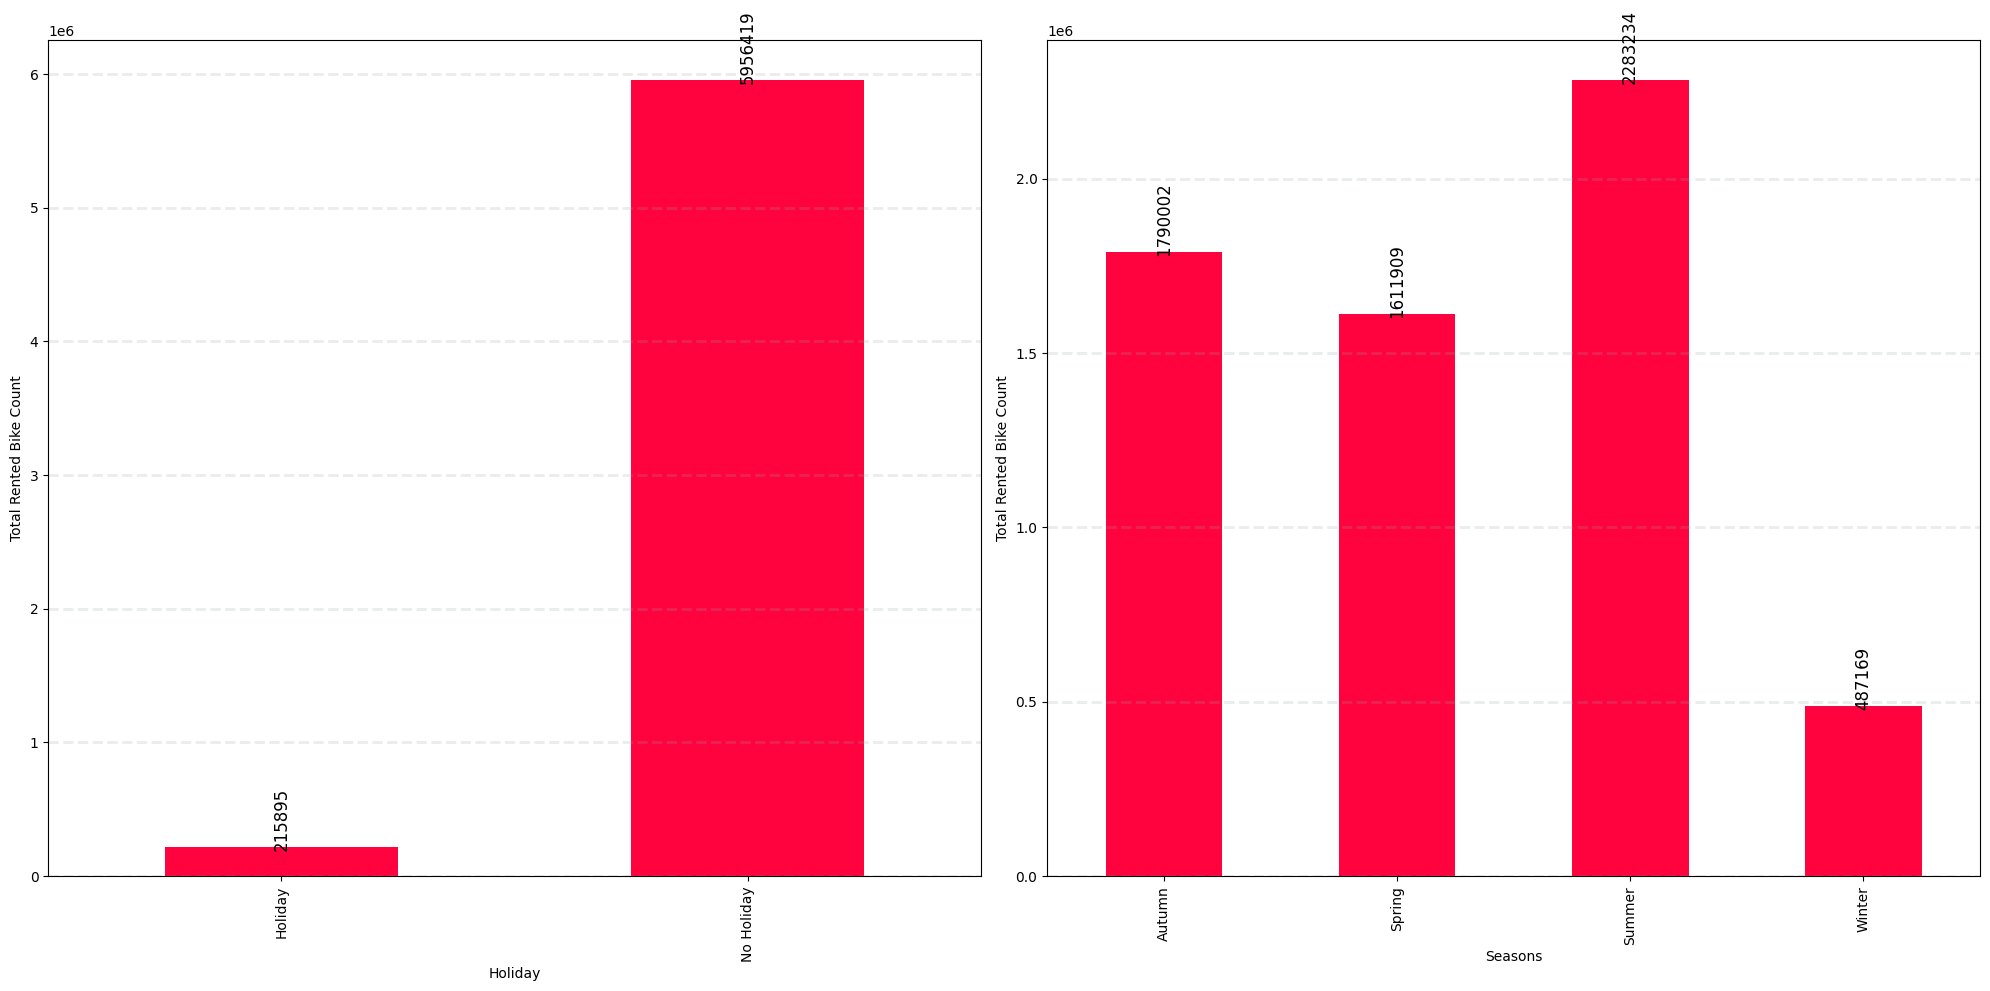

In [28]:
#Find out the relationship between categorical variable and dependent feature Rented Bike Count

fig = plt.figure(figsize = (20,10))
for index,column in enumerate(categorical_features) :
    plt.subplot(1,2,index+1)
    dataset=df1.copy()
    dataset.groupby(feature)['Rented Bike Count'].sum().plot(kind='bar',color="#ff033e")
    feature = df1[column]
    ax = fig.gca()
    plt.ylabel('Total Rented Bike Count')
    plt.tight_layout()
    plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.2)
    for p in ax.patches:
        ax.annotate(round(p.get_height()),(p.get_x() + p.get_width()/2,p.get_height()),ha='center',size= 12, rotation=90)


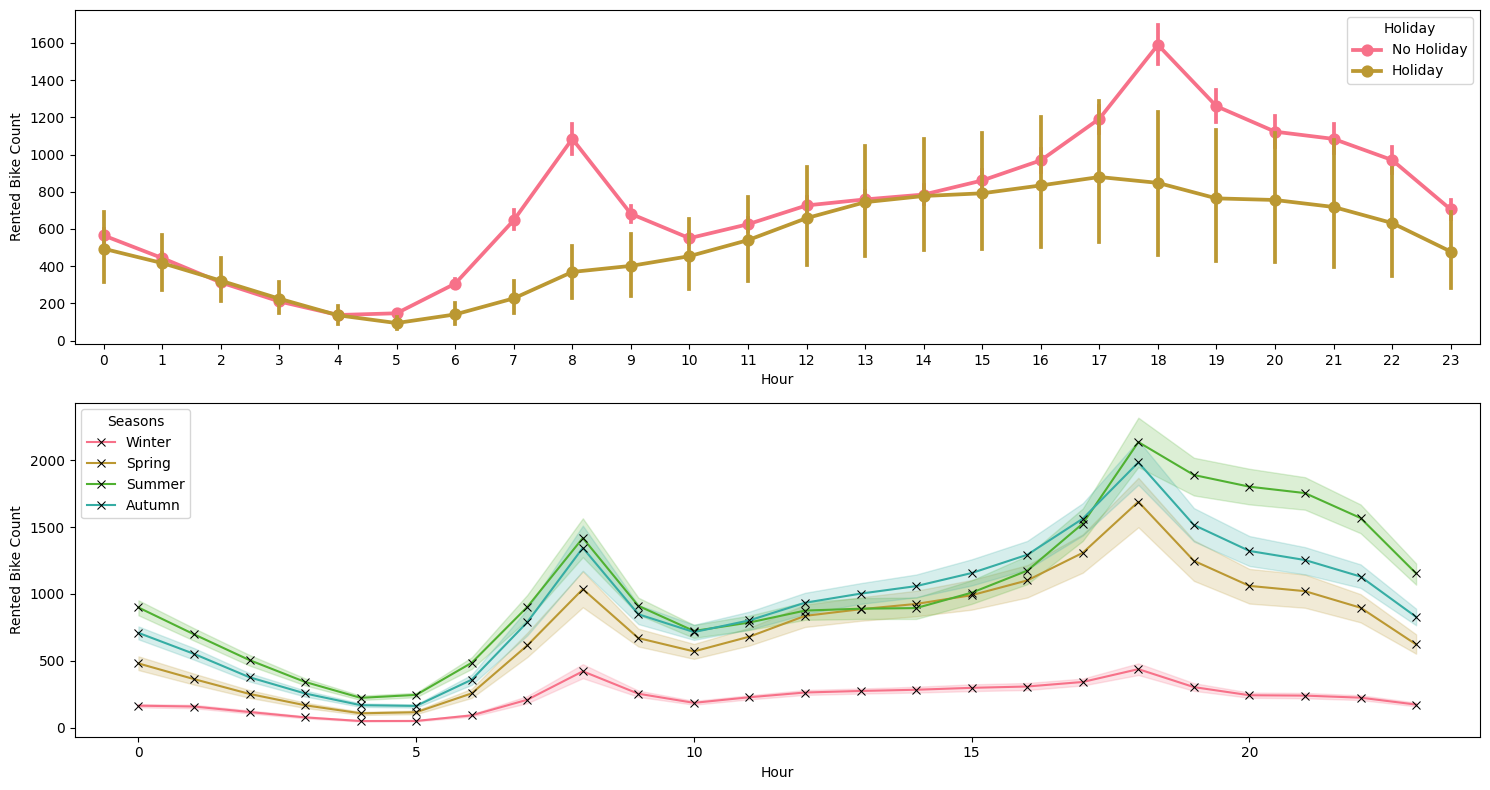

In [29]:
fig, axs = plt.subplots(nrows=2,ncols=1,figsize=(15,8), dpi=100)
sns.pointplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[0], 
              hue="Holiday")
sns.lineplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[1], 
              hue="Seasons", marker="x",markeredgecolor="black")
plt.tight_layout()

## **4. Feature Engineering On Data**


1. [Encode](https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features) categorical data into one-hot vectors.
2. Identify Inputs and Target
3. [Scale](https://scikit-learn.org/stable/modules/preprocessing.html#scaling-features-to-a-range) values in numeric columns to a $(0,1)$ range.
4. Split the dataset into training and validation sets.


### *4.1 _ Encoding Data*

Encode categorical data in both encoder and check accuracy of encoders:
1. oh_df : OneHotEncoder Data 
2. le_df : LabelEncoder Data 

####4.1.1 _ Apply OneHotEncoder on Data



Since machine learning models can only be trained with numeric data, we need to convert categorical data to numbers. A common technique is to use one-hot encoding for categorical columns.

<img src="https://i.imgur.com/n8GuiOO.png" width="640">

One hot encoding involves adding a new binary (0/1) column for each unique category of a categorical column.

In [30]:
# ohe_df=pd.get_dummies(df1, columns=['Seasons', 'Holiday', 'Year'], drop_first=True, dtype=int)
# ohe_df

One-hot encoding approach eliminates the order but it causes the number of columns to expand vastly. So for columns with more unique values try using other techniques like LabelEncoding

#### 4.1.2 _ Apply LabelEncoder

In [31]:
# Encode labels of multiple columns at ones using LabelEncoder
le_df= df1.apply(LabelEncoder().fit_transform)
le_df

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Day,Month,Year
0,252,0,111,28,22,1779,0,0,0,3,1,0,11,0
1,202,1,108,29,8,1779,0,0,0,3,1,0,11,0
2,171,2,103,30,10,1779,0,0,0,3,1,0,11,0
3,105,3,101,31,9,1779,0,0,0,3,1,0,11,0
4,76,4,103,27,23,1779,0,0,0,3,1,0,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,990,19,205,25,26,1673,0,0,0,0,1,29,10,1
8756,754,20,197,28,23,1779,0,0,0,0,1,29,10,1
8757,685,21,189,30,3,1747,0,0,0,0,1,29,10,1
8758,703,22,184,32,10,1639,0,0,0,0,1,29,10,1


Checking Season Column Data

In [32]:
df1.groupby("Seasons").count()  #for checking raw data

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Solar Radiation,Rainfall,Snowfall,Holiday,Day,Month,Year
Seasons,,,,,,,,,,,,,
Autumn,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937
Spring,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160
Summer,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208
Winter,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160


In [33]:
le_df.groupby('Seasons').count()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Solar Radiation,Rainfall,Snowfall,Holiday,Day,Month,Year
Seasons,,,,,,,,,,,,,
0,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937
1,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160
2,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208,2208
3,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160,2160


0 : Autumn , 1 : Spring , 2 : Summer , 3 : Winter

### **Checking Distribution and Outliers in DataFrame**

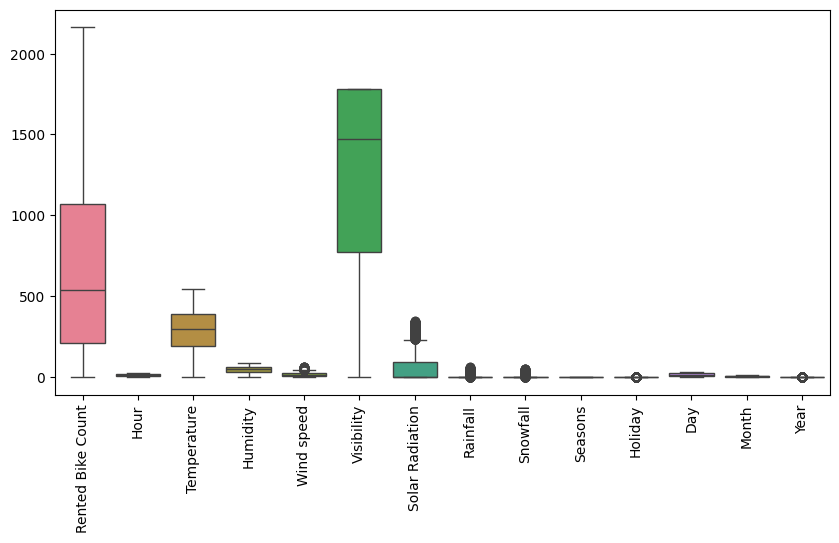

In [34]:
#checking for outliers
plt.figure(figsize=(10,5))   # for define chart size
plt.xticks(rotation =90)     #plot X-axis ticks in 90 degree rotation for clear visible
sns.boxplot(data = le_df)    #box plot of le_df data frame raw data
plt.show()

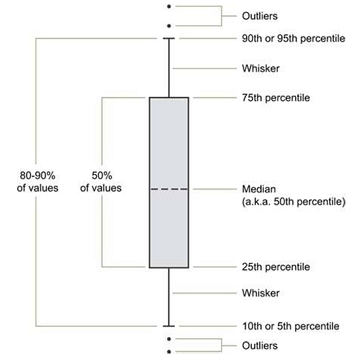

Target Parameter `Rented Bike Count` distributation analysis

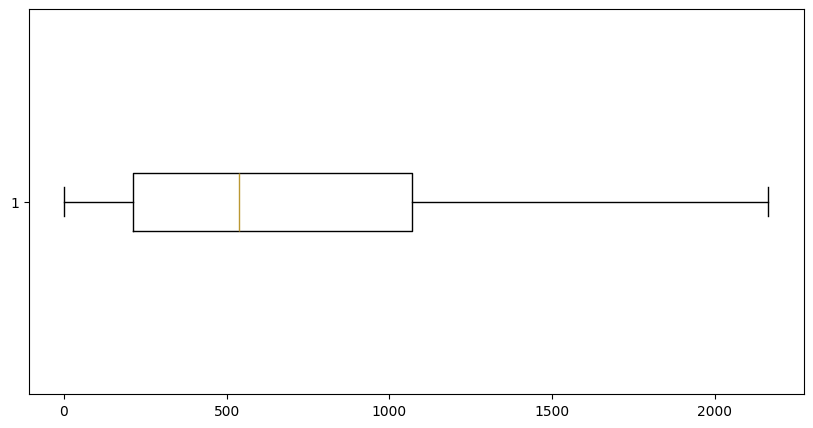

In [35]:
plt.figure(figsize=(10,5))
plt.boxplot(le_df['Rented Bike Count'],vert=False)
plt.show()

Outline detection using Interquartile Range

**Square Root**
The square root method is typically used when your data is moderately skewed. Now using the square root (e.g., sqrt(x)) is  a transformation that has a moderate effect on distribution shape. It is generally used to reduce right skewed data. Finally, the square root can be applied on zero values and is most commonly used on counted data.

Square Root Transformation: Transform the values from y to √y.

-----------------------------------------------------------------


**Log Transformation**
The logarithmic is a strong transformation that has a major effect on distribution shape. This technique is, as the square root method, oftenly used for reducing right skewness. Worth noting, however, is that it can not be applied to zero or negative values.

Log Transformation: Transform the values from y to log(y).

--------------------------------------------------------------------


**Cube root transformation** involves converting x to x^ (1/3). This is a fairly strong transformation with a substantial effect on distribution shape: but is weaker than the logarithm. It can be applied to negative and zero values too. Negatively skewed data

Cube Root Transformation: Transform the values from y to y^(1/3).

Text(0.5, 1.0, 'cube root')

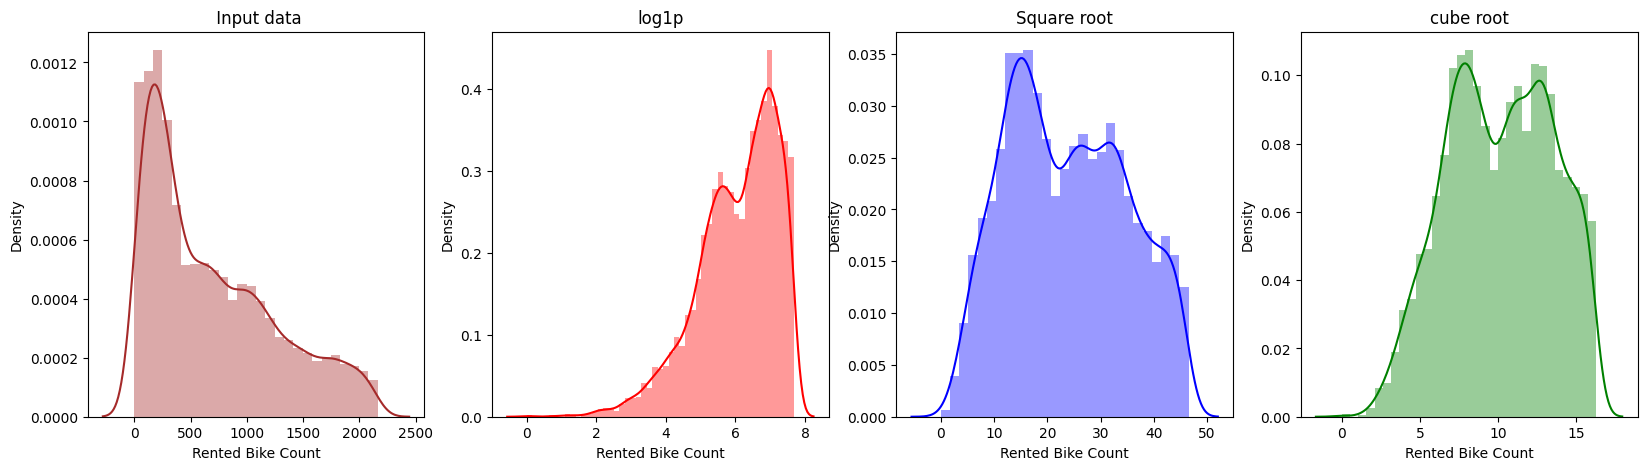

In [36]:
#apply diffrent tranformation technique and checking data distributation
fig,axes = plt.subplots(1,4,figsize=(20,5))
sns.distplot((le_df['Rented Bike Count']),ax=axes[0],color='brown').set_title(" Input data")
sns.distplot(np.log1p(le_df['Rented Bike Count']+0.0000001),ax=axes[1],color='red').set_title("log1p") #transform only posible in positive value and >0 value so add 0.0000001 in data
sns.distplot(np.sqrt(le_df['Rented Bike Count']),ax=axes[2], color='blue').set_title("Square root")
sns.distplot(np.cbrt(le_df['Rented Bike Count']*2),ax=axes[3], color='green').set_title("cube root")

In [37]:
import scipy.stats as stats

In [38]:
def plotvariable(df,variable):
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)   #means 1 row, 2 Columns and 1st plot
  df[variable].hist(bins=30)

  ##QQ plot
  plt.subplot(1,2,2)
  stats.probplot(df[variable], dist='norm',plot=plt)
  plt.show()


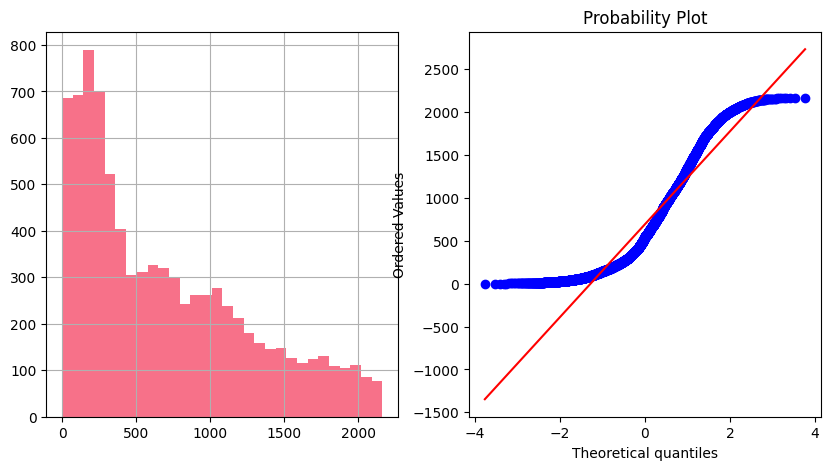

In [39]:
plotvariable(le_df,'Rented Bike Count')

our `Rented Bike Count` target is not normally distributed ,so we need to make some transformations before supply to the model

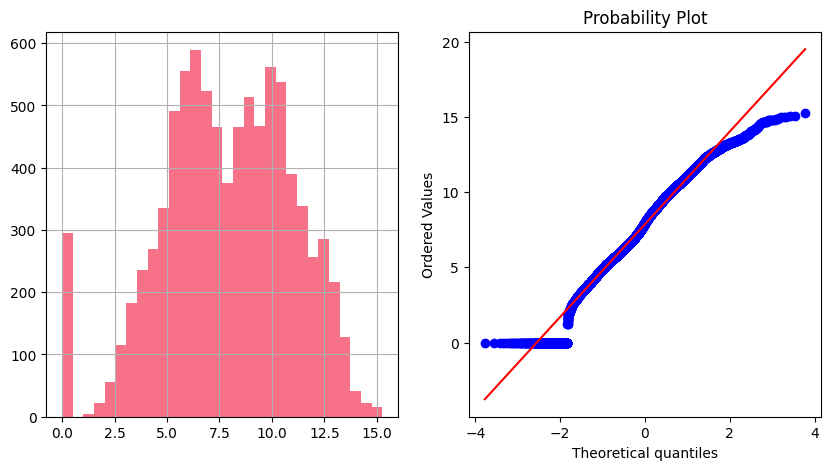

In [40]:
data["RBC_qb"]=np.cbrt(data['Rented Bike Count']) #try cube root technique to convert positive screwd to normal distributation

plotvariable(data,"RBC_qb")

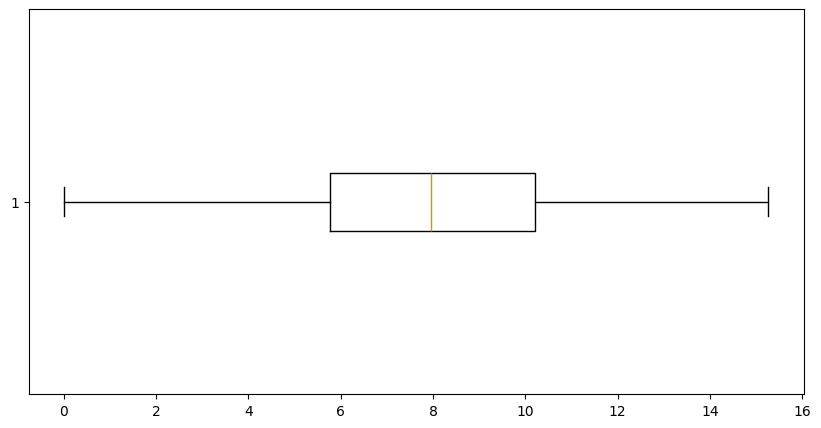

In [41]:
plt.figure(figsize=(10,5))
plt.boxplot(data["RBC_qb"],vert=False)
plt.show()

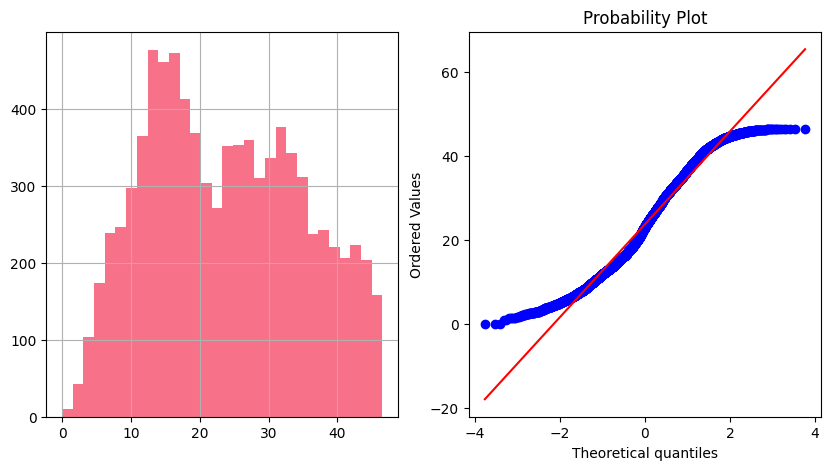

In [42]:
le_df['Rented Bike Count']=np.sqrt(le_df['Rented Bike Count'])

plotvariable(le_df,'Rented Bike Count')

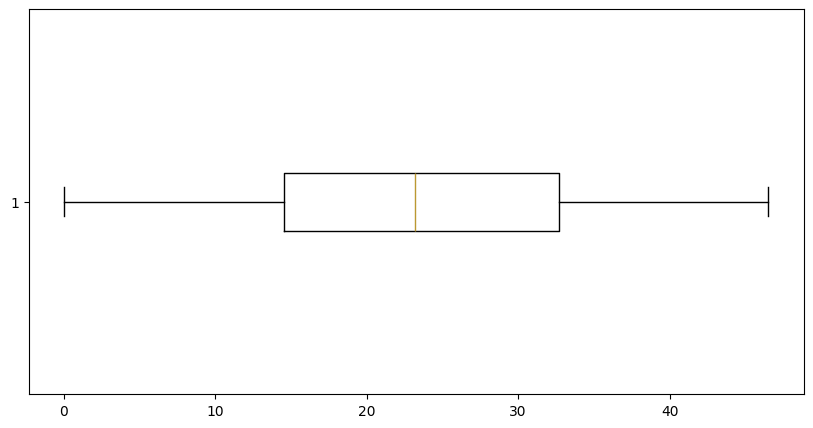

In [43]:
plt.figure(figsize=(10,5))
plt.boxplot(le_df["Rented Bike Count"],vert=False)
plt.show()

Normal Distributation achieved

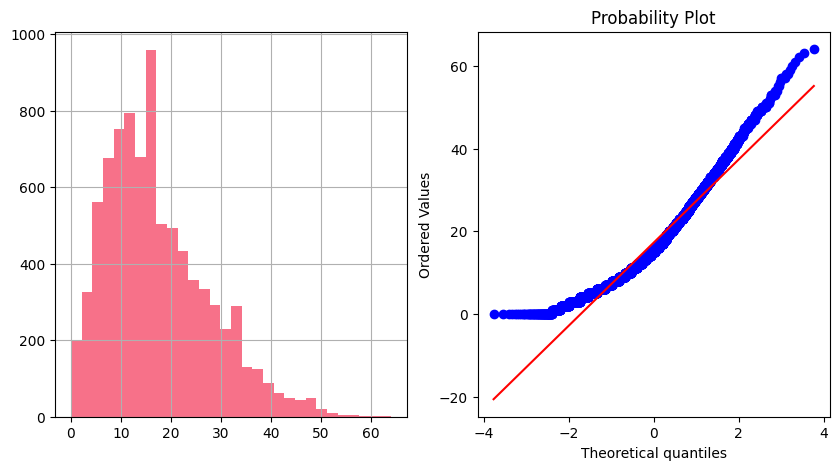

In [44]:
plotvariable(le_df,'Wind speed')

Does not look like a normal distribution but rather a right screwed distributation so we need to apply transformation

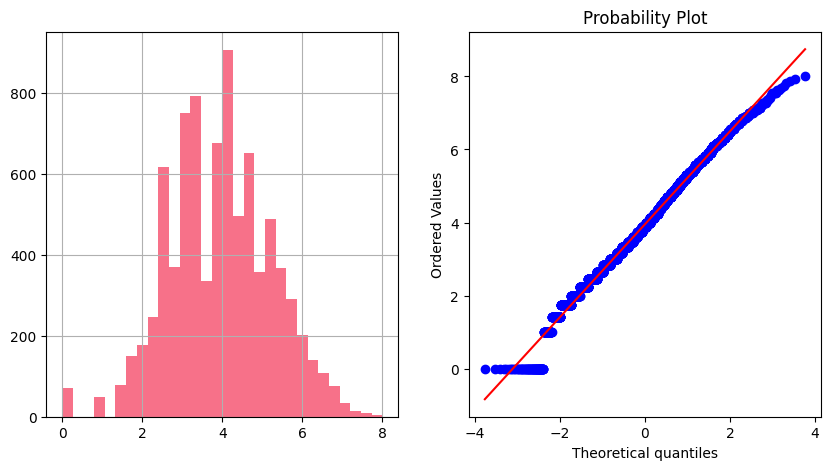

In [45]:
le_df['Wind speed']=np.sqrt(le_df['Wind speed'])

plotvariable(le_df,'Wind speed')

Normal Distribution Achieved

### *4.2 _ Identify Inputs and Targets*

- The column `Rented Bike Count` contains the value we need to predict i.e. it's the target column.
- Data from all the other columns (except the first and the last column) can be used as inputs to the model.
 

>Create a list `X` of column names containing data that can be used as input to train the model, and identify the target column as the variable `y`.

In [46]:
X=le_df.drop('Rented Bike Count',axis=1)
y=le_df['Rented Bike Count']

### *4.3 _ Spliting Training and Testing Set*
Finally, let's split the dataset into a training and testing set. We'll use a randomly select 30% subset of the data for validation. Also, we'll use just the numeric and encoded columns.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [48]:
# Let's check the shape of the train and test dataset

print(f'The shape of the train and test set for the independent variables are : X_train = {X_train.shape}, X_test = {X_test.shape}')
print(f'The shape of the train and test set for the dependent variables are : y_train = {y_train.shape}, y_test = {y_test.shape}')

The shape of the train and test set for the independent variables are : X_train = (6772, 13), X_test = (1693, 13)
The shape of the train and test set for the dependent variables are : y_train = (6772,), y_test = (1693,)


## **5. Scaling Data and Model Building Using Various Regression Techniques**

Regression searches for relationships among variables. 

The dependent features are called the dependent variables, outputs, or responses. 

The independent features are called the independent variables, inputs, regressors, or predictors.

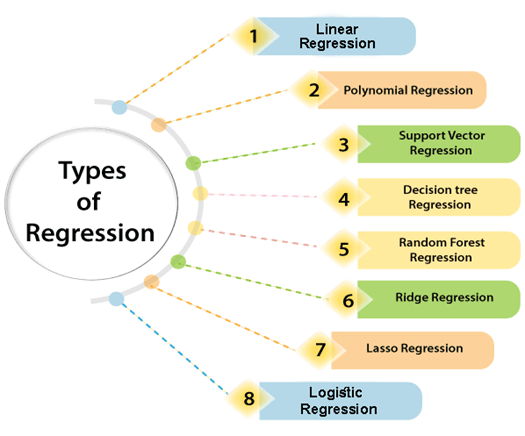

**Different Models Accuracy Checking Using Robust Scaler**

In [49]:
def predict(ml_model,X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=10)
    rob =RobustScaler()

    X_train = rob.fit_transform(X_train)
    X_test = rob.transform(X_test)

    model=ml_model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    plt.scatter(y_pred,y_test,color='b')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    print(f'R^2 is {model.score(X_test,y_test)}\n Adj R^2 is {1-(1-model.score(X_test,y_test))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)}\n RMSE is: {root_mean_squared_error(y_test,y_pred)}')
    

**R2** shows how well terms (data points) fit a curve or line. 
**Adjusted R2** also indicates how well terms fit a curve or line, but adjusts for the number of terms in a model. If you add more and more useless variables to a model, adjusted r-squared will decrease. If you add more useful variables, adjusted r-squared will increase.

Adjusted R2 will always be less than or equal to R2.



**R2** assumes that every single variable explains the variation in the dependent variable. 

**The adjusted R2** tells you the percentage of variation explained by only the independent variables that actually affect the dependent variable.

<html>
<img src="https://4.bp.blogspot.com/-wG7IbjTfE6k/XGUvqm7TCVI/AAAAAAAAAZU/vpH1kuKTIooKTcVlnm1EVRCXLVZM9cPNgCLcBGAs/s1600/formula-MAE-MSE-RMSE-RSquared.JPG" height="600" width="600" alt="bike">
</html>




**MSE** is a risk function that allows us to calculate the average squared difference between a feature’s or variable’s predicted and actual value.

**RMSE** is an abbreviation for Root Mean Square Error, which is the square root of the value obtained from the Mean Square Error function.

**Linear Regression :**

<html>
<img src="https://miro.medium.com/max/2600/1*2ZnDb5b6UtBZ41Wy90MTkw.jpeg" height="300" width="600" alt="bike">
</html>

Here is multiple dependent variables, So its call a multiple linear regression



<html>
<img src="https://miro.medium.com/max/1160/1*Jfx203VYFtcM958gbFsiXA.png" height="300" width="600" alt="bike">
</html>

R^2 is 0.6491356453783304
 Adj R^2 is 0.6464190065396873
 RMSE is: 6.774952707030622


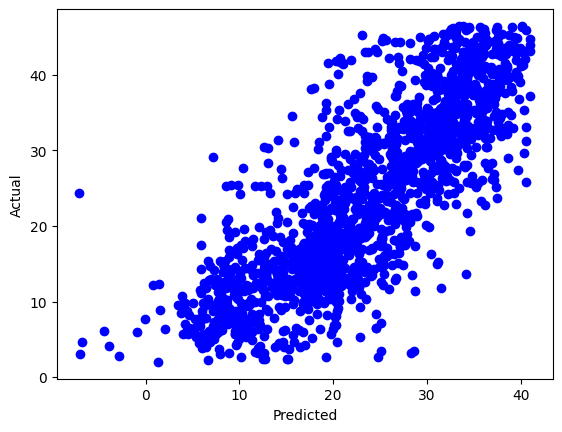

In [50]:
predict(LinearRegression(),X,y)

**Decision Tree Regressor :**

<html>
<img src="https://user-images.githubusercontent.com/49559408/66479235-186a5200-ead7-11e9-8d4c-2389faa853bd.PNG" height="250" width="600" alt="bike">
</html>



R^2 is 0.8078891380835969
 Adj R^2 is 0.806401680546424
 RMSE is: 5.013171979929951


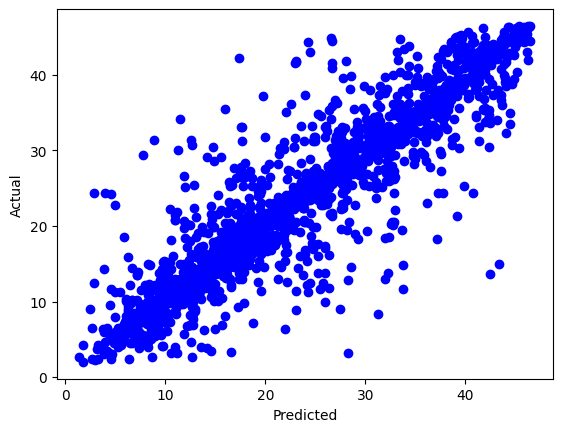

In [51]:
predict(DecisionTreeRegressor(),X,y)

**Random Forest Regressor:**

<html>
<img src="https://miro.medium.com/max/1376/1*yp3XJHsgRGcnh26Ndi7dxA.png" height="250" width="600" alt="bike">
</html>



R^2 is 0.9030406065783555
 Adj R^2 is 0.9022898786959961
 RMSE is: 3.5614888440081827


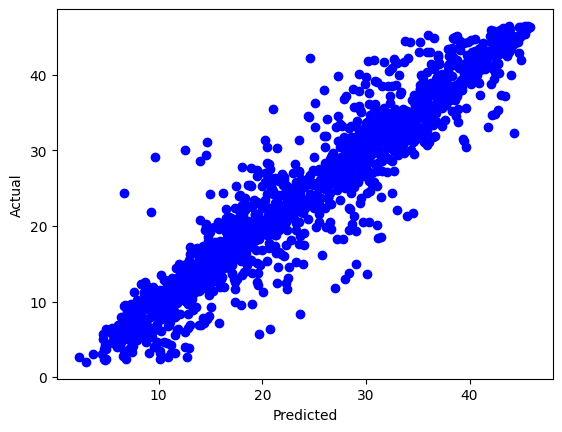

In [52]:
predict(RandomForestRegressor(),X,y)

<html>
<img src="https://rohitgr7.github.io/content/images/2019/03/Screenshot-from-2019-03-27-23-09-47-1.png" height="250" width="600" alt="bike">
</html>



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1034
[LightGBM] [Info] Number of data points in the train set: 6772, number of used features: 13
[LightGBM] [Info] Start training from score 23.784708
R^2 is 0.911416478934921
 Adj R^2 is 0.9107306029528804
 RMSE is: 3.4041846790750223


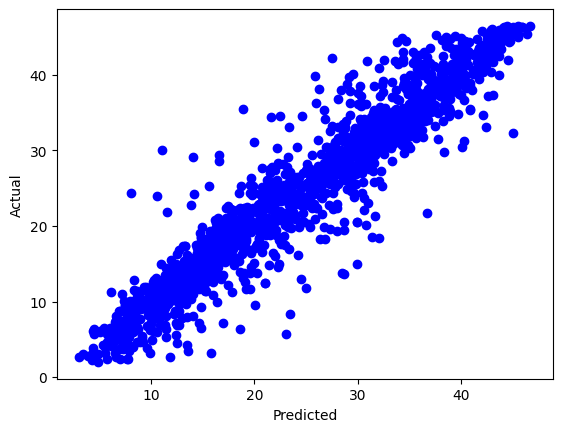

In [53]:
predict(LGBMRegressor(),X,y)

**Models Accuracy Checking Using MinMaxScaler**

In [54]:
def predict_mm(ml_model,X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=10)
    mm =MinMaxScaler()

    X_train = mm.fit_transform(X_train)
    X_test = mm.transform(X_test)

    model=ml_model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    plt.scatter(y_pred,y_test,color='g')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    print(f'R^2 is {model.score(X_test,y_test)}\n Adj R^2 is {1-(1-model.score(X_test,y_test))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)}\n RMSE is: {root_mean_squared_error(y_test,y_pred)}')
    

R^2 is 0.6491356453783307
 Adj R^2 is 0.6464190065396876
 RMSE is: 6.77495270703062


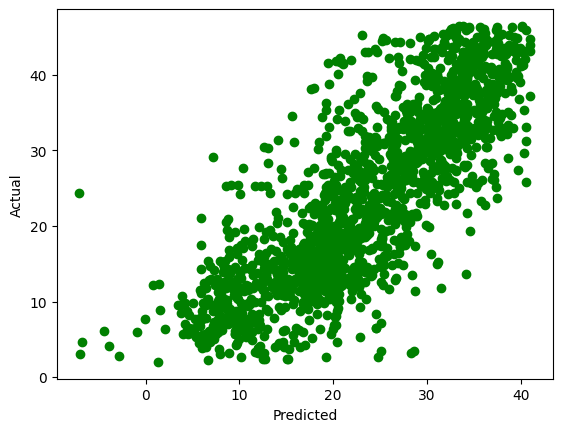

In [55]:
predict_mm(LinearRegression(),X,y)

R^2 is 0.8138971862726986
 Adj R^2 is 0.8124562472742144
 RMSE is: 4.934158691122246


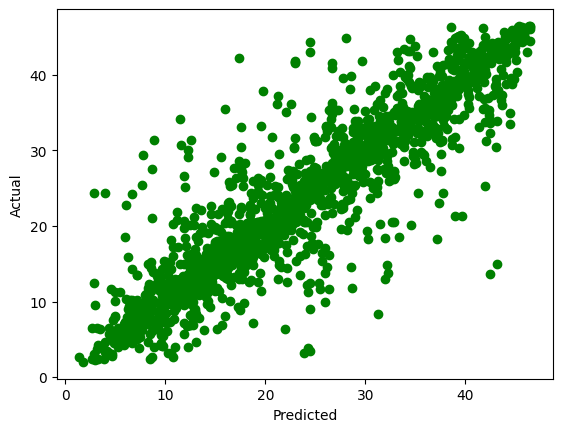

In [56]:
predict_mm(DecisionTreeRegressor(),X,y)

R^2 is 0.9015419434115685
 Adj R^2 is 0.9007796118239273
 RMSE is: 3.588907565556578


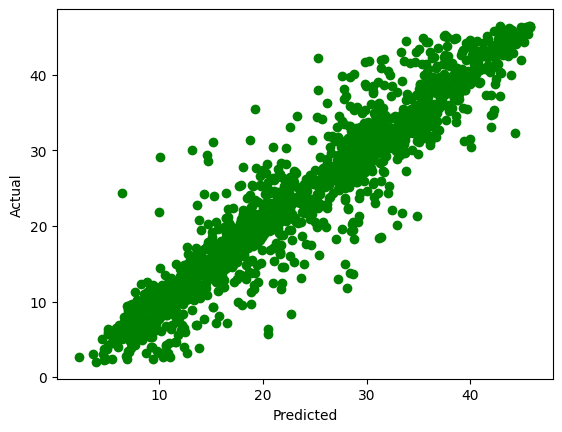

In [57]:
predict_mm(RandomForestRegressor(),X,y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1044
[LightGBM] [Info] Number of data points in the train set: 6772, number of used features: 13
[LightGBM] [Info] Start training from score 23.784708
R^2 is 0.9126520262434183
 Adj R^2 is 0.9119757167384538
 RMSE is: 3.3803608312882236


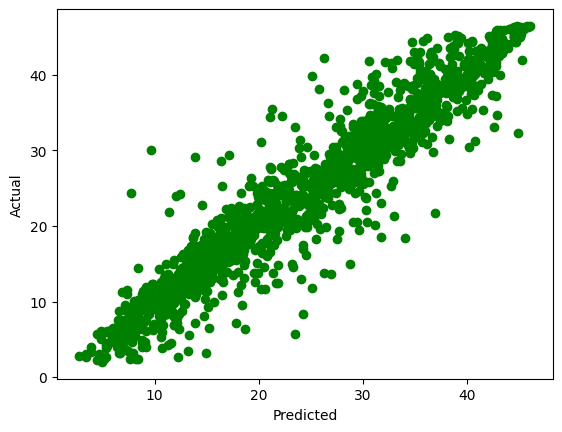

In [58]:
predict_mm(LGBMRegressor(),X,y)

**Models Accuracy Checking Using Standard Scaler**

In [59]:
def predict_ss(ml_model,X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=10)
    ss =StandardScaler()

    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)

    model=ml_model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    plt.scatter(y_pred,y_test,color='r')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    print(f'R^2 is {model.score(X_test,y_test)} \n Adj R^2 is {1-(1-model.score(X_test,y_test))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)}\n RMSE is: {root_mean_squared_error(y_test,y_pred)}')
    pred_y_df=pd.DataFrame({"Actual Value":y_test,"Predicted Value":y_pred,"Difference":y_test-y_pred})
    print(pred_y_df[0:10])

Checking Actual value and Predicated value with it's differenace 

R^2 is 0.6491356453783306 
 Adj R^2 is 0.6464190065396875
 RMSE is: 6.774952707030621
      Actual Value  Predicted Value  Difference
5028     33.749074        29.272325    4.476749
5121     11.224972         9.780839    1.444134
4191     33.955854        34.049407   -0.093554
8498     16.852300        20.185298   -3.332998
8072     41.713307        20.694436   21.018871
3300     33.075671        30.660028    2.415642
1461      7.615773         5.903167    1.712606
1324      4.472136         5.706469   -1.234333
8128     39.862263        37.513135    2.349128
16       21.931712        19.440960    2.490752


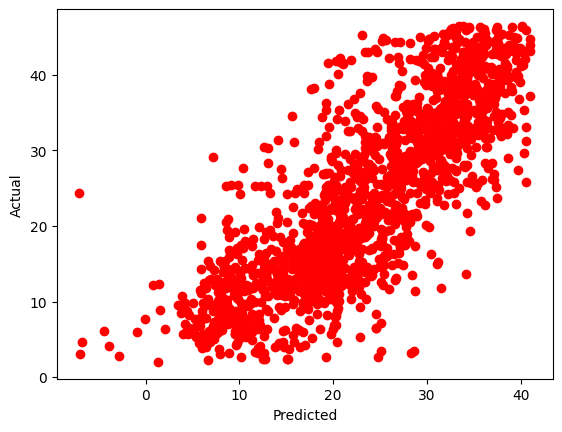

In [60]:
predict_ss(LinearRegression(),X,y)

R^2 is 0.8033791720866782 
 Adj R^2 is 0.8018567952177841
 RMSE is: 5.071674860079795
      Actual Value  Predicted Value  Difference
5028     33.749074        33.555923    0.193151
5121     11.224972         5.000000    6.224972
4191     33.955854        36.000000   -2.044146
8498     16.852300        18.248288   -1.395988
8072     41.713307        23.021729   18.691578
3300     33.075671        31.670175    1.405496
1461      7.615773         9.899495   -2.283722
1324      4.472136         4.898979   -0.426844
8128     39.862263        36.918830    2.943433
16       21.931712        21.656408    0.275304


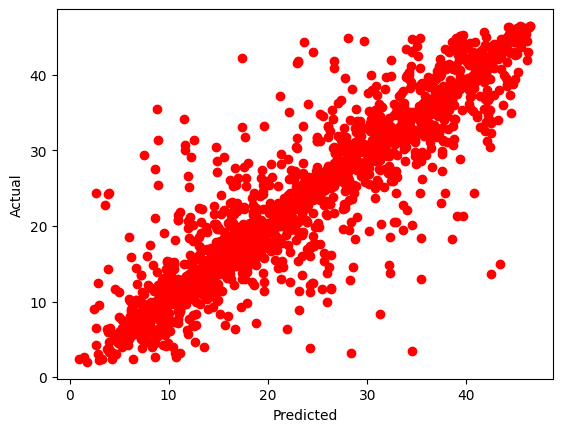

In [61]:
predict_ss(DecisionTreeRegressor(),X,y)

R^2 is 0.9036380258856803 
 Adj R^2 is 0.9028919236441757
 RMSE is: 3.5504997601221593
      Actual Value  Predicted Value  Difference
5028     33.749074        32.360058    1.389016
5121     11.224972         6.750213    4.474759
4191     33.955854        36.228541   -2.272688
8498     16.852300        17.179710   -0.327410
8072     41.713307        34.501219    7.212088
3300     33.075671        31.938029    1.137642
1461      7.615773         8.140240   -0.524467
1324      4.472136         5.608314   -1.136178
8128     39.862263        37.640331    2.221931
16       21.931712        20.119097    1.812615


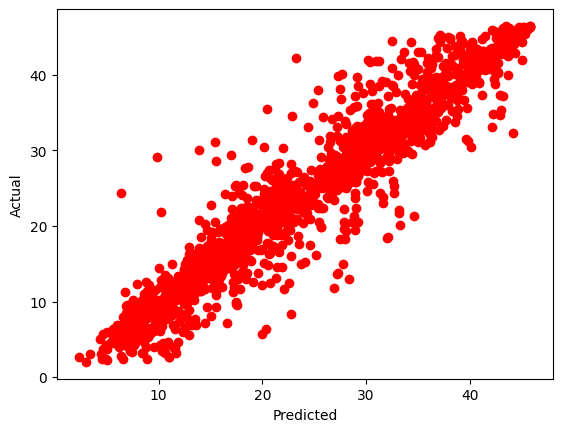

In [62]:
predict_ss(RandomForestRegressor(),X,y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1050
[LightGBM] [Info] Number of data points in the train set: 6772, number of used features: 13
[LightGBM] [Info] Start training from score 23.784708
R^2 is 0.9132529122963251 
 Adj R^2 is 0.9125812552742002
 RMSE is: 3.3687136404834725
      Actual Value  Predicted Value  Difference
5028     33.749074        32.314278    1.434796
5121     11.224972         6.413008    4.811964
4191     33.955854        38.563623   -4.607770
8498     16.852300        17.305923   -0.453623
8072     41.713307        32.054113    9.659194
3300     33.075671        31.079802    1.995869
1461      7.615773         7.619930   -0.004156
1324      4.472136         5.832807   -1.360671
8128     39.862263        38.261001    1.601262
16       21.931712        1

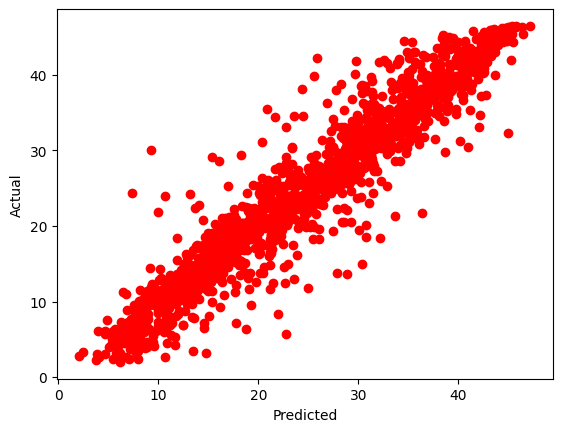

In [63]:
predict_ss(LGBMRegressor(),X,y)

In [64]:
import lightgbm
import time
from math import sqrt
from sklearn import preprocessing, model_selection, metrics
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

In [65]:
models = [
           ['LinearRegression: ',              LinearRegression()],
           ['Lasso: ',                         Lasso()],
           ['Ridge: ',                         Ridge()],
           ['KNeighborsRegressor: ',           neighbors.KNeighborsRegressor()],
           ['SVR:' ,                           SVR(kernel='rbf')],
           ['DecisionTree ',                   DecisionTreeRegressor(random_state=42)],
           ['RandomForest ',                   RandomForestRegressor(random_state=42)],
           ['ExtraTreeRegressor :',            ExtraTreesRegressor(random_state=42)],
           ['GradientBoostingRegressor: ',     GradientBoostingRegressor(random_state=42)],
           ['XGBRegressor: ',                  xgb.XGBRegressor(random_state=42)] ,
           ['Light-GBM: ',                     lightgbm.LGBMRegressor(num_leaves=41, n_estimators=200,random_state=42)],
           ['MLPRegressor: ', MLPRegressor(  activation='logistic', solver='sgd',learning_rate='adaptive',max_iter=1000,learning_rate_init=0.01,alpha=0.01)]
]

In [66]:
import dagshub
import mlflow

dagshub.init(repo_owner = REPO_OWNER, repo_name = REPO_NAME, mlflow=True)
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("base_models")

Accessing as Tchaikovsky29

Initialized MLflow to track repo "Tchaikovsky29/Bicycle-Demand-Prediction"

Repository Tchaikovsky29/Bicycle-Demand-Prediction initialized!

<Experiment: artifact_location='mlflow-artifacts:/e41de5805e4941508cc5471f1e0f488c', creation_time=1770559915353, experiment_id='0', last_update_time=1770559915353, lifecycle_stage='active', name='base_models', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [67]:
def log_model_params(algo_name, model):
    """
    Logs selected hyperparameters of the trained model to MLflow.
    Works for sklearn, XGBoost, and LightGBM models.
    """

    # Define important parameters per model type
    PARAMS_MAP = {
        "LinearRegression": ["fit_intercept", "normalize"],
        "Lasso": ["alpha", "max_iter"],
        "Ridge": ["alpha", "max_iter"],
        "KNeighborsRegressor": ["n_neighbors", "weights", "metric"],
        "SVR": ["kernel", "C", "gamma", "epsilon"],
        "DecisionTreeRegressor": ["max_depth", "min_samples_split", "min_samples_leaf"],
        "RandomForestRegressor": ["n_estimators", "max_depth", "min_samples_split"],
        "ExtraTreesRegressor": ["n_estimators", "max_depth", "min_samples_split"],
        "GradientBoostingRegressor": ["n_estimators", "learning_rate", "max_depth"],
        "XGBRegressor": ["n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree"],
        "LGBMRegressor": ["n_estimators", "learning_rate", "num_leaves", "max_depth"],
        "MLPRegressor": ["activation", "solver", "alpha", "learning_rate", "learning_rate_init", "max_iter"]
    }

    params = {}
    model_class_name = model.__class__.__name__

    if model_class_name in PARAMS_MAP:
        model_params = model.get_params()
        for param in PARAMS_MAP[model_class_name]:
            if param in model_params:
                params[param] = model_params[param]

    # Log algorithm name explicitly
    params["model_name"] = algo_name.strip()

    mlflow.log_params(params)

In [68]:
model_data = []
with mlflow.start_run(run_name = "All_models") as parent_run:
    for name,curr_model in models :
        with mlflow.start_run(run_name = name, nested = True) as child_run:
            curr_model_data = {}
            curr_model.random_state = 78
            curr_model_data["Name"] = name
            start = time.time()
            curr_model.fit(X_train,y_train)
            end = time.time()
            curr_model_data["Train_Time"] = end - start
            curr_model_data["Train_R2_Score"] = metrics.r2_score(y_train,curr_model.predict(X_train))
            curr_model_data["Test_R2_Score"] = metrics.r2_score(y_test,curr_model.predict(X_test))
            curr_model_data["Test_RMSE_Score"] = sqrt(mean_squared_error(y_test,curr_model.predict(X_test)))
            
            log_model_params(name, curr_model)
            
            for key, value in curr_model_data.items():
                if key != "Name":
                    mlflow.log_metric(key, value)
            
            model_data.append(curr_model_data)

🏃 View run LinearRegression:  at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/0/runs/61ba91ab41e0435a999b3e055be883ca
🧪 View experiment at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/0
🏃 View run Lasso:  at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/0/runs/8119cc1ea2a347ffa14e02cab5363a6a
🧪 View experiment at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/0
🏃 View run Ridge:  at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/0/runs/a0ce26a71a4949f0870deaebd7eb0d0b
🧪 View experiment at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/0
🏃 View run KNeighborsRegressor:  at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/0/runs/44bb2e6b28e14a128fdb03ea8c40529a
🧪 View experiment at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.ml

In [69]:
model_data

[{'Name': 'LinearRegression: ',
  'Train_Time': 0.00601506233215332,
  'Train_R2_Score': 0.6479526016556851,
  'Test_R2_Score': 0.6595301444306261,
  'Test_RMSE_Score': 6.424241909403667},
 {'Name': 'Lasso: ',
  'Train_Time': 0.006424903869628906,
  'Train_R2_Score': 0.6364920654911759,
  'Test_R2_Score': 0.6454227122615182,
  'Test_RMSE_Score': 6.555985884338435},
 {'Name': 'Ridge: ',
  'Train_Time': 0.006125688552856445,
  'Train_R2_Score': 0.6479525651915246,
  'Test_R2_Score': 0.6595265227237115,
  'Test_RMSE_Score': 6.424276077861006},
 {'Name': 'KNeighborsRegressor: ',
  'Train_Time': 0.021160364151000977,
  'Train_R2_Score': 0.7597423123967926,
  'Test_R2_Score': 0.6388079679653031,
  'Test_RMSE_Score': 6.616855241125787},
 {'Name': 'SVR:',
  'Train_Time': 3.6613683700561523,
  'Train_R2_Score': 0.45722161562825236,
  'Test_R2_Score': 0.46519214009967025,
  'Test_RMSE_Score': 8.05158614114114},
 {'Name': 'DecisionTree ',
  'Train_Time': 0.1048738956451416,
  'Train_R2_Score': 1.

#### Compare Models Accuracy 

In [70]:
df_all_model=pd.DataFrame(model_data)
df_all_model

,Name,Train_Time,Train_R2_Score,Test_R2_Score,Test_RMSE_Score
0,LinearRegression:,0.006015,0.647953,0.659530,6.424242
1,Lasso:,0.006425,0.636492,0.645423,6.555986
2,Ridge:,0.006126,0.647953,0.659527,6.424276
3,KNeighborsRegressor:,0.021160,0.759742,0.638808,6.616855
4,SVR:,3.661368,0.457222,0.465192,8.051586
5,DecisionTree,0.104874,1.000000,0.797859,4.950050
6,RandomForest,6.404642,0.985825,0.889794,3.654984
7,ExtraTreeRegressor :,3.491827,1.000000,0.896280,3.545789
8,GradientBoostingRegressor:,1.934630,0.889918,0.874460,3.900985
9,XGBRegressor:,0.491973,0.979832,0.899020,3.498647


As per above results Train and Test R2 Score is nearby in good model.

Near 1 Score is very good model.

So, In above results best models are : 

|No|Model Name| Model Accuracy Score in % |
|--|----------|------------|
|6|	RandomForest|	88%|
|7|	ExtraTreeRegressor| 89%|
|8|	GradientBoostingRegressor|87%|
|9|	XGBRegressor|89%|
|10|	Light-GBM|90%|

## ***6. HyperParameter Tuning***
Apply on GradientBoostingRegressor Model and improve Accuracy of Model.

 Choose the best Hyperparameters

It’s a bit confusing to choose the best hyperparameters for boosting. But once you know how the boosting algorithms work, then you are able to choose it. Here are the best ones that I have chosen, learning_rate, max_depth, and the n_estimators. The max_depth and n_estimators are also the same parameters we chose in a random forest. Here we are taking an extra that is the learning_rate.

Call the Boosting regressor constructor and define the parameters.
Here you will make the list of all possibilities for each of the Hyperparameters.

In [71]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
gbr = GradientBoostingRegressor(random_state=42)

param_distributions = {
    "n_estimators": randint(200, 1200),
    "learning_rate": uniform(0.01, 0.1),
    "max_depth": randint(2, 6),
    "min_samples_leaf": randint(1, 20),
    "subsample": uniform(0.7, 0.3),
    "loss": ["squared_error", "huber"]
}

In [72]:
mlflow.set_experiment("Fine_tuning_best_model")

with mlflow.start_run(run_name="GBR_RandomSearch"):

    random_search = RandomizedSearchCV(
        estimator=gbr,
        param_distributions=param_distributions,
        n_iter=50,
        cv=3,
        scoring="r2",
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_

    # Log best hyperparameters
    mlflow.log_params(random_search.best_params_)

    # Log metrics
    mlflow.log_metric("best_cv_r2", random_search.best_score_)
    mlflow.log_metric(
        "train_r2",
        metrics.r2_score(y_train, best_model.predict(X_train))
    )
    mlflow.log_metric(
        "test_r2",
        metrics.r2_score(y_test, best_model.predict(X_test))
    )
    mlflow.log_metric(
        "test_rmse",
        sqrt(metrics.mean_squared_error(y_test, best_model.predict(X_test)))
    )
    
    mlflow.log_param("n_iter", random_search.n_iter)
    mlflow.log_param("cv_folds", random_search.cv)
    mlflow.log_param("scoring", random_search.scoring)

    # Log model
    mlflow.sklearn.log_model(best_model, name="gbr_model")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
🏃 View run GBR_RandomSearch at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/1/runs/1a1fae3c9a5446bbb31ac5f4a28422e6
🧪 View experiment at: https://dagshub.com/Tchaikovsky29/Bicycle-Demand-Prediction.mlflow/#/experiments/1


view selected best parameter by model

**Now apply best selected paramter and checking result**

In [ ]:
X=le_df.drop('Rented Bike Count',axis=1)
y=le_df['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

gbr_params = {'n_estimators': 1000,
          'max_depth': 6,
          'min_samples_split': 10,
          'learning_rate': 0.1,
          'loss': 'huber'}

gbr = GradientBoostingRegressor(**gbr_params)

gbr.fit(X_train_std, y_train)

print("Model Accuracy: %.3f" % gbr.score(X_test_std, y_test))

mse = mean_squared_error(y_test, gbr.predict(X_test_std))
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))
print('Root Mean Squared Error is {:.4f} '.format(np.sqrt(mean_squared_error(y_test,
                                                    gbr.predict(X_test)))) )
 

Model Accuracy: 0.903
The mean squared error (MSE) on test set: 11.7507
Root Mean Squared Error is 3.4626 


Using Hyperperameters tuning, we improved the accuracy of our model from 87% to **90%**